In [37]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import scienceplots

no_cycles = 1
# Stadardised Formation Cycling Bham group
# exp = pybamm.Experiment( [("Charge at C/20 until 4.2 V",
#                            "Hold at 4.2 V for 1 hours", 
#                            "Hold at 4.2 V until 2.5 mA", 
#                            "Discharge at C/20 until 2.5 V",
#                            "Charge at C/20 until 3.8 V",
#                            "Hold at 3.8 V for 1 hours"
#                            )]* no_cycles)


exp = pybamm.Experiment(
    [("Charge at C/20 until 4.2 V",
      "Rest for 5 hours",
      "Discharge at C/20 until 2.5 V",
      "Rest for 5 hours",
      )]* no_cycles )

param=pybamm.ParameterValues("Chen2020")

models = [pybamm.lithium_ion.DFN(),
          pybamm.lithium_ion.SPMe(),
          pybamm.lithium_ion.SPM(),
          pybamm.lithium_ion.SPM({"particle": "uniform profile"})]
models_names = ["DFN", "SPMe", "SPM", "RM"]

solver = pybamm.CasadiSolver(mode="safe")
sims = [pybamm.Simulation(model, parameter_values=param,
                          experiment=exp, solver=solver) for model in models]
sols = [sim.solve(initial_soc=0) for sim in sims]

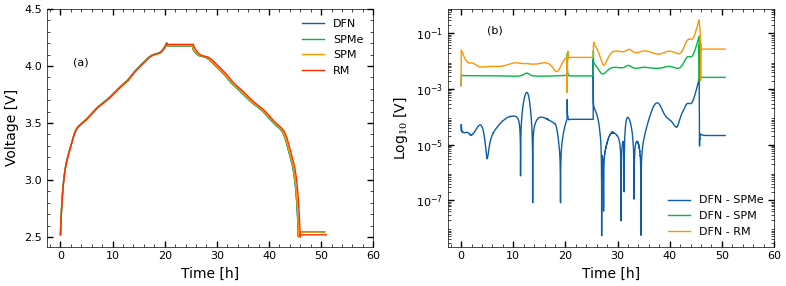

In [38]:
import matplotlib.ticker as ticker
import numpy as np

def set_plotting_format(mode):
    plt.style.use(["science", "std-colors"])
    if mode == "presentation":
        plt.rcParams.update(
            {
                "font.family": "sans-serif",
                "text.usetex": False,
                "font.size": 12,  
                "axes.labelsize": 14,  
                "lines.linewidth": 2,
                "xtick.major.size": 6,  
                "ytick.major.size": 6,  
                "xtick.minor.size": 3, 
                "ytick.minor.size": 3,  
                "xtick.major.width": 1.5,  
                "ytick.major.width": 1.5,  
                "xtick.minor.width": 1,  
                "ytick.minor.width": 1,  
            }
        )
    elif mode == "paper":
        plt.rcParams.update(
            {
                "font.family": "sans-serif",
                "text.usetex": False,
                "font.size": 8, 
                "axes.labelsize": 10,  
                "xtick.major.size": 4,  
                "ytick.major.size": 4,  
                "xtick.minor.size": 2, 
                "ytick.minor.size": 2,  
                "xtick.major.width": 1,  
                "ytick.major.width": 1, 
                "xtick.minor.width": 0.5,  
                "ytick.minor.width": 0.5,  
            }
        )

set_plotting_format("paper")  # input should be either "presentation" or "paper"

fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharex=True)


# First subplot
for index, model_name in enumerate(models_names[:4]):
    time = sols[index]["Time [h]"].entries
    voltage = sols[index]["Terminal voltage [V]"].entries
    axes[0].plot(time, voltage, label=model_name)

axes[0].legend()  # Increased legend font size
axes[0].set_xlabel("Time [h]")
axes[0].set_ylabel("Voltage [V]")
axes[0].text(2.5, 4.0, "(a)")

# Set x-axis ticks and labels for the first subplot using a loop
xticks = np.arange(0, 70, 10)
axes[0].set_xticks(xticks)
axes[0].set_xticklabels(xticks)

# Set y-axis ticks for the first subplot using a loop
yticks = np.arange(2.5, 5, 0.5)
axes[0].set_yticks(yticks)

# Second subplot
t_max = max(sol["Time [s]"].entries[-1] for sol in sols)
t = np.linspace(0, t_max, 10000)

for index in range(1, 4):
    error = sols[0]["Terminal voltage [V]"](t) - sols[index]["Terminal voltage [V]"](t)
    axes[1].semilogy(t / 3600, np.abs(error), label=f"{models_names[0]} - {models_names[index]}")

axes[1].legend()  # Increased legend font size
axes[1].set_xlabel("Time [h]")
axes[1].set_ylabel("Log$_{10}$ [V]")
axes[1].text(5, 1e-1, "(b)")

# Set x-axis ticks and labels for the second subplot using a loop
axes[1].set_xticks(xticks)
axes[1].set_xticklabels(xticks)

# Adjusting the number of ticks on the y-axis for the second subplot
axes[1].yaxis.set_major_locator(ticker.LogLocator(base=10, numticks=4))  # Use LogLocator for y-axis

plt.tight_layout()
plt.savefig("figures/fig1.png", dpi=300)